# CheXNet → MURA Domain Transfer

Transfer learning from **CheXNet** (DenseNet-121 pretrained on chest X-rays) to **MURA** (bone X-rays, `XR_FOREARM` subset).

**Experiments**
1. Frozen CheXNet backbone (train classifier only)
2. Fine-tuned CheXNet (train all layers, low LR)
3. DenseNet-121 from scratch (random init — control)

Plus **Grad-CAM** localization on abnormal cases.

> Before running: **Runtime → Change runtime type → T4 GPU**. Then run all cells top to bottom.

In [9]:
# Cell 1 - Confirm the runtime has the T4 GPU
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [10]:
# Environment bootstrap — pull the project (code + weights + data) onto the Colab VM
import os

REPO_URL = "https://github.com/sofiaorlov9821/CheXNet.git"
CHEXNET  = "/content/CheXNet"

if not os.path.exists(CHEXNET):
    !git clone {REPO_URL} {CHEXNET}
else:
    !cd {CHEXNET} && git pull

assert os.path.exists(f"{CHEXNET}/model.pth.tar"), "clone failed — check repo access"
print("[OK] Project ready at", CHEXNET)

Already up to date.
[OK] Project ready at /content/CheXNet


In [11]:
# All imports + global configuration (the single setup cell)
%pip install grad-cam -q

import sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torchvision.models import densenet121

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Make the local CheXNet repo importable (append = don't shadow torch/torchvision)
if CHEXNET not in sys.path:
    sys.path.append(CHEXNET)
from model import DenseNet121                      # CheXNet DenseNet-121 wrapper

# ---- Global config ----
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH     = f"{CHEXNET}/model.pth.tar"
MURA_DIR      = f"{CHEXNET}/MURA_MSK_Xrays_files"
BODY_PART     = "XR_FOREARM"
BATCH_SIZE    = 32
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
SEED          = 42
EPOCHS        = 10

assert DEVICE.type == "cuda", "No GPU — Runtime > Change runtime type > T4 GPU"
print("Device:", torch.cuda.get_device_name(0))

Device: Tesla T4


## 1. Data — MURA preprocessing & loading

`SquarePad` (preserve proportions) → resize 224 → augment (train only) → ImageNet normalize.
Labels come from the study-folder name: `_positive` → 1 (abnormal), `_negative` → 0 (normal).

In [12]:
# SquarePad, transforms, and the MURA dataset
class SquarePad:
    """Pad a PIL image to a square (longer edge) before resizing, so anatomy isn't distorted."""
    def __call__(self, image):
        w, h = image.size
        s = max(w, h)
        left, top = (s - w) // 2, (s - h) // 2
        return TF.pad(image, (left, top, s - w - left, s - h - top), fill=0)

train_tf = transforms.Compose([
    SquarePad(), transforms.Resize((224, 224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    SquarePad(), transforms.Resize((224, 224)),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class MURADataset(Dataset):
    """MURA radiographs as a binary (normal/abnormal) per-image dataset.
    Label parsed from the study-folder name ('positive' -> 1, 'negative' -> 0)."""
    def __init__(self, root, body_part, split, transform=None):
        self.transform = transform
        self.samples = []
        base = os.path.join(root, split, body_part)
        for patient in sorted(os.listdir(base)):
            pdir = os.path.join(base, patient)
            if not os.path.isdir(pdir):
                continue
            for study in sorted(os.listdir(pdir)):
                sdir = os.path.join(pdir, study)
                if not os.path.isdir(sdir):
                    continue
                label = 1 if "positive" in study.lower() else 0
                for f in sorted(os.listdir(sdir)):
                    if f.lower().endswith(".png"):
                        self.samples.append((os.path.join(sdir, f), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

print("[OK] transforms + MURADataset defined")

[OK] transforms + MURADataset defined


In [13]:
# Build datasets / loaders and compute class balance
train_ds = MURADataset(MURA_DIR, BODY_PART, "train", train_tf)
valid_ds = MURADataset(MURA_DIR, BODY_PART, "valid", eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

pos_tr = sum(l for _, l in train_ds.samples); neg_tr = len(train_ds) - pos_tr
pos_va = sum(l for _, l in valid_ds.samples); neg_va = len(valid_ds) - pos_va
pos_weight = torch.tensor([neg_tr / max(pos_tr, 1)])          # for BCEWithLogitsLoss
print(f"TRAIN {len(train_ds)} | abnormal {pos_tr} / normal {neg_tr}")
print(f"VALID {len(valid_ds)} | abnormal {pos_va} / normal {neg_va}")
print(f"pos_weight (neg/pos) = {pos_weight.item():.3f}")

TRAIN 1825 | abnormal 661 / normal 1164
VALID 301 | abnormal 151 / normal 150
pos_weight (neg/pos) = 1.761


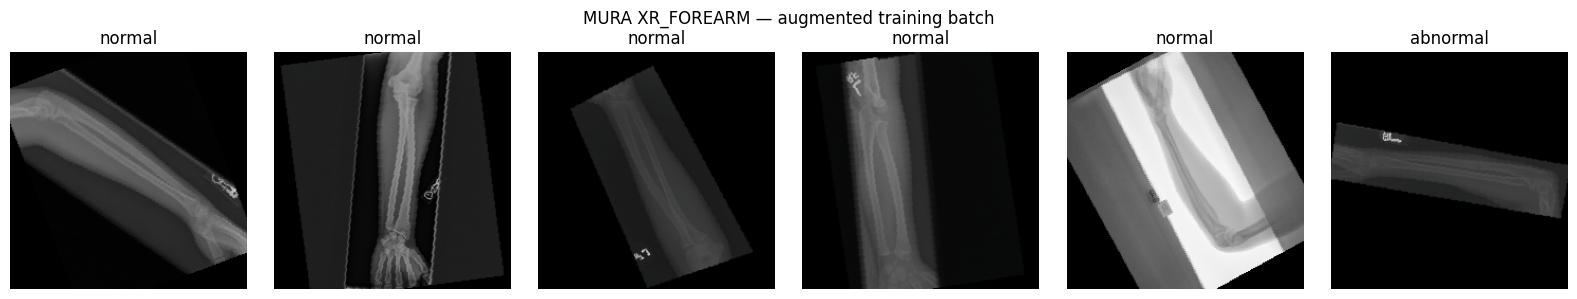

Batch: torch.Size([32, 3, 224, 224])


In [14]:
# Sanity check — one augmented training batch
imgs, labels = next(iter(train_loader))
mean, std = np.array(IMAGENET_MEAN), np.array(IMAGENET_STD)
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(np.clip(imgs[i].permute(1, 2, 0).numpy() * std + mean, 0, 1))
    ax.set_title("abnormal" if labels[i] == 1 else "normal"); ax.axis("off")
plt.suptitle("MURA XR_FOREARM — augmented training batch"); plt.tight_layout(); plt.show()
print("Batch:", imgs.shape)

## 2. Model utilities — weight loader, loss, train / eval

Loads CheXNet weights (strips the `module.` prefix, fixes legacy `norm.1`→`norm1` keys) and defines the shared training/evaluation loops. `run_training` keeps the **best validation-AUC** checkpoint — the same rule for all three experiments, so the comparison is fair.

In [15]:
# CheXNet weight loader + shared loss / train / eval helpers
def load_chexnet_backbone(ckpt_path, device):
    """Load CheXNet weights into DenseNet121(14). Handles the 'state_dict' key,
    the 'module.' DataParallel prefix, and old torchvision 'norm.1'->'norm1' naming."""
    model = DenseNet121(14)
    state = torch.load(ckpt_path, map_location="cpu")["state_dict"]
    pattern = re.compile(r"^(.*denselayer\d+\.(?:norm|relu|conv))\."
                         r"((?:[12])\.(?:weight|bias|running_mean|running_var))$")
    fixed = {}
    for k, v in state.items():
        k = k[len("module."):] if k.startswith("module.") else k
        m = pattern.match(k)
        if m:
            k = m.group(1) + m.group(2)
        fixed[k] = v
    missing, unexpected = model.load_state_dict(fixed, strict=False)
    print(f"[OK] CheXNet weights loaded | missing={len(missing)} unexpected={len(unexpected)}")
    return model.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))

def train_one_epoch(model, loader, optimizer, device):
    model.train(); running = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs).squeeze(1), labels)
        loss.backward(); optimizer.step()
        running += loss.item() * imgs.size(0)
    return running / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, device):
    """Validation metrics at threshold 0.5: Accuracy, AUC, F1, Precision, Recall."""
    model.eval(); probs, ys = [], []
    for imgs, labels in loader:
        probs.append(torch.sigmoid(model(imgs.to(device)).squeeze(1)).cpu())
        ys.append(labels)
    p = torch.cat(probs).numpy(); y = torch.cat(ys).numpy(); pred = (p >= 0.5).astype(int)
    return {"AUC": roc_auc_score(y, p),"Accuracy": accuracy_score(y, pred), 
            "F1": f1_score(y, pred, zero_division=0),
            "Precision": precision_score(y, pred, zero_division=0),
            "Recall": recall_score(y, pred, zero_division=0)}

def run_training(model, optimizer, tag, ckpt_name, epochs=EPOCHS):
    """Train for `epochs`, keep the best validation-AUC checkpoint, reload it, return best metrics."""
    best_auc, best = 0.0, {}
    for e in range(1, epochs + 1):
        loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        m = evaluate(model, valid_loader, DEVICE)
        print(f"Epoch {e:02d} | loss {loss:.4f} | Acc {m['Accuracy']:.3f}  AUC {m['AUC']:.3f}  F1 {m['F1']:.3f}  "
              f"P {m['Precision']:.3f}  R {m['Recall']:.3f}")
        if m["AUC"] > best_auc:
            best_auc, best = m["AUC"], m
            torch.save(model.state_dict(), ckpt_name)
    model.load_state_dict(torch.load(ckpt_name))
    print(f"\n[{tag}] BEST:", {k: round(v, 3) for k, v in best.items()})
    torch.cuda.empty_cache()
    return best

## 3. Experiment 1 — Frozen CheXNet backbone

Freeze the entire CheXNet backbone; train only a fresh 1-node classifier. Measures how useful CheXNet's chest-X-ray features are *as-is* for bone abnormality detection.

In [16]:
torch.manual_seed(SEED)

def build_frozen_model():
    model = load_chexnet_backbone(CKPT_PATH, DEVICE)
    for p in model.parameters():
        p.requires_grad = False                                   # freeze everything
    n = model.densenet121.classifier[0].in_features
    model.densenet121.classifier = nn.Linear(n, 1).to(DEVICE)     # fresh 1-logit head
    print("Trainable:", sum(p.numel() for p in model.parameters() if p.requires_grad),
          "/", sum(p.numel() for p in model.parameters()))
    return model

exp1_model = build_frozen_model()
opt1 = optim.Adam(filter(lambda p: p.requires_grad, exp1_model.parameters()), lr=1e-3)
exp1_metrics = run_training(exp1_model, opt1, "Exp 1 - Frozen CheXNet", "exp1_frozen.pth")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[OK] CheXNet weights loaded | missing=0 unexpected=0
Trainable: 1025 / 6954881
Epoch 01 | loss 0.8884 | Acc 0.512  AUC 0.580  F1 0.667  P 0.507  R 0.974
Epoch 02 | loss 0.8766 | Acc 0.575  AUC 0.591  F1 0.533  P 0.593  R 0.483
Epoch 03 | loss 0.8530 | Acc 0.585  AUC 0.604  F1 0.593  P 0.583  R 0.603
Epoch 04 | loss 0.8481 | Acc 0.558  AUC 0.612  F1 0.621  P 0.545  R 0.722
Epoch 05 | loss 0.8449 | Acc 0.565  AUC 0.612  F1 0.631  P 0.549  R 0.742
Epoch 06 | loss 0.8456 | Acc 0.581  AUC 0.610  F1 0.583  P 0.583  R 0.583
Epoch 07 | loss 0.8427 | Acc 0.565  AUC 0.596  F1 0.639  P 0.547  R 0.768
Epoch 08 | loss 0.8462 | Acc 0.598  AUC 0.609  F1 0.598  P 0.600  R 0.596
Epoch 09 | loss 0.8380 | Acc 0.588  AUC 0.613  F1 0.637  P 0.571  R 0.722
Epoch 10 | loss 0.8573 | Acc 0.601  AUC 0.606  F1 0.597  P 0.605  R 0.589

[Exp 1 - Frozen CheXNet] BEST: {'AUC': np.float64(0.613), 'Accuracy': 0.588, 'F1': 0.637, 'Precision': 0.571, 'Recall': 0.722}


## 4. Experiment 2 — Fine-tuned CheXNet

Unfreeze all layers; train end-to-end with a low LR (1e-4) so CheXNet's features adapt to bone without being erased.

In [17]:
torch.manual_seed(SEED)

def build_finetuned_model():
    model = load_chexnet_backbone(CKPT_PATH, DEVICE)              # all layers trainable by default
    n = model.densenet121.classifier[0].in_features
    model.densenet121.classifier = nn.Linear(n, 1).to(DEVICE)
    print("Trainable:", sum(p.numel() for p in model.parameters() if p.requires_grad), "(all layers)")
    return model

exp2_model = build_finetuned_model()
opt2 = optim.Adam(exp2_model.parameters(), lr=1e-4)              # low LR protects pretrained weights
exp2_metrics = run_training(exp2_model, opt2, "Exp 2 - Fine-Tuned CheXNet", "exp2_finetuned.pth")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[OK] CheXNet weights loaded | missing=0 unexpected=0
Trainable: 6954881 (all layers)
Epoch 01 | loss 0.8672 | Acc 0.595  AUC 0.658  F1 0.619  P 0.586  R 0.656
Epoch 02 | loss 0.7972 | Acc 0.668  AUC 0.726  F1 0.648  P 0.692  R 0.609
Epoch 03 | loss 0.6979 | Acc 0.721  AUC 0.801  F1 0.716  P 0.731  R 0.702
Epoch 04 | loss 0.6418 | Acc 0.734  AUC 0.805  F1 0.704  P 0.798  R 0.629
Epoch 05 | loss 0.5974 | Acc 0.748  AUC 0.831  F1 0.719  P 0.815  R 0.642
Epoch 06 | loss 0.5762 | Acc 0.774  AUC 0.835  F1 0.736  P 0.888  R 0.629
Epoch 07 | loss 0.5631 | Acc 0.767  AUC 0.842  F1 0.760  P 0.787  R 0.735
Epoch 08 | loss 0.5447 | Acc 0.801  AUC 0.865  F1 0.774  P 0.896  R 0.682
Epoch 09 | loss 0.5214 | Acc 0.777  AUC 0.860  F1 0.727  P 0.947  R 0.589
Epoch 10 | loss 0.5277 | Acc 0.764  AUC 0.846  F1 0.758  P 0.782  R 0.735

[Exp 2 - Fine-Tuned CheXNet] BEST: {'AUC': np.float64(0.865), 'Accuracy': 0.801, 'F1': 0.774, 'Precision': 0.896, 'Recall': 0.682}


## 5. Experiment 3 — DenseNet-121 from scratch (control)

Random initialization, no pretraining. Isolates and quantifies the value of CheXNet's weights.

In [18]:
torch.manual_seed(SEED)

def build_scratch_model():
    model = densenet121(weights=None)                            # random init — no pretraining
    model.classifier = nn.Linear(model.classifier.in_features, 1)
    print("Trainable:", sum(p.numel() for p in model.parameters()), "(all random)")
    return model.to(DEVICE)

exp3_model = build_scratch_model()
opt3 = optim.Adam(exp3_model.parameters(), lr=1e-3)             # standard LR for scratch
exp3_metrics = run_training(exp3_model, opt3, "Exp 3 - From Scratch", "exp3_scratch.pth")

Trainable: 6954881 (all random)
Epoch 01 | loss 0.9209 | Acc 0.561  AUC 0.634  F1 0.383  P 0.651  R 0.272
Epoch 02 | loss 0.8692 | Acc 0.558  AUC 0.622  F1 0.387  P 0.636  R 0.278
Epoch 03 | loss 0.8672 | Acc 0.601  AUC 0.651  F1 0.641  P 0.585  R 0.709
Epoch 04 | loss 0.8698 | Acc 0.502  AUC 0.601  F1 0.668  P 0.502  R 1.000
Epoch 05 | loss 0.8805 | Acc 0.492  AUC 0.552  F1 0.061  P 0.417  R 0.033
Epoch 06 | loss 0.8683 | Acc 0.571  AUC 0.643  F1 0.486  P 0.610  R 0.404
Epoch 07 | loss 0.8803 | Acc 0.558  AUC 0.596  F1 0.486  P 0.583  R 0.417
Epoch 08 | loss 0.8682 | Acc 0.548  AUC 0.602  F1 0.292  P 0.683  R 0.185
Epoch 09 | loss 0.8689 | Acc 0.641  AUC 0.693  F1 0.614  P 0.667  R 0.570
Epoch 10 | loss 0.8516 | Acc 0.588  AUC 0.599  F1 0.488  P 0.648  R 0.391

[Exp 3 - From Scratch] BEST: {'AUC': np.float64(0.693), 'Accuracy': 0.641, 'F1': 0.614, 'Precision': 0.667, 'Recall': 0.57}


## 6. Results summary

           Exp 1: Frozen  Exp 2: Fine-Tuned  Exp 3: From Scratch
Accuracy           0.588              0.801                0.641
AUC                0.613              0.865                0.693
F1                 0.637              0.774                0.614
Precision          0.571              0.896                0.667
Recall             0.722              0.682                0.570


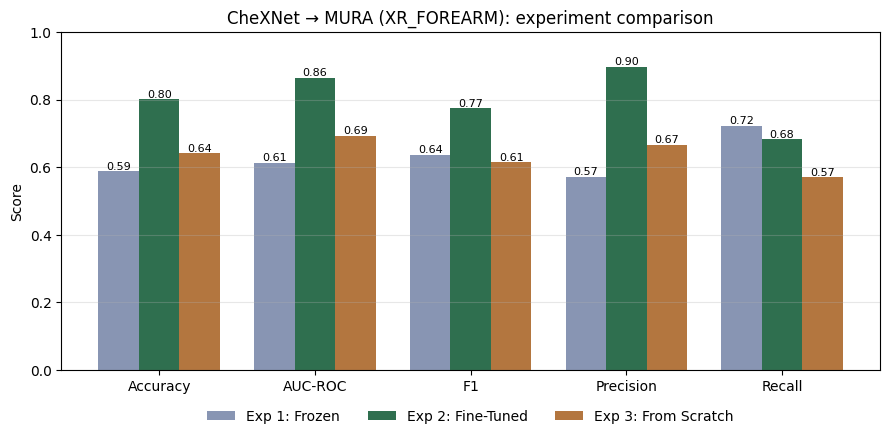

,Exp 1: Frozen,Exp 2: Fine-Tuned,Exp 3: From Scratch
Accuracy,0.588,0.801,0.641
AUC,0.613,0.865,0.693
F1,0.637,0.774,0.614
Precision,0.571,0.896,0.667
Recall,0.722,0.682,0.570


In [22]:
# Summary — metrics as rows, experiments as columns (matches the report table)
summary = pd.DataFrame({
    "Exp 1: Frozen":       exp1_metrics,
    "Exp 2: Fine-Tuned":   exp2_metrics,
    "Exp 3: From Scratch": exp3_metrics,
}).loc[["Accuracy", "AUC", "F1", "Precision", "Recall"]].astype(float).round(3)
print(summary.to_string())

# Grouped bar chart: x-axis = metrics, one bar per experiment (value labels on top)
labels = ["Accuracy", "AUC-ROC", "F1", "Precision", "Recall"]
exps   = ["Exp 1: Frozen", "Exp 2: Fine-Tuned", "Exp 3: From Scratch"]
colors = ["#8895b3", "#2f6f4f", "#b3763f"]          # feel free to change
x = np.arange(len(labels)); w = 0.26

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (exp, col) in enumerate(zip(exps, colors)):
    bars = ax.bar(x + (i - 1) * w, summary[exp].values, w, label=exp, color=col)
    for r in bars:
        ax.annotate(f"{r.get_height():.2f}",
                    (r.get_x() + r.get_width() / 2, r.get_height()),
                    ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.0); ax.set_ylabel("Score")
ax.set_title("CheXNet \u2192 MURA (XR_FOREARM): experiment comparison")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("experiment_summary.png", dpi=200, bbox_inches="tight")
plt.show()
summary

## 7. Grad-CAM — localizing abnormal predictions (fine-tuned model)

Grad-CAM localizes the evidence behind an **abnormal** prediction, so it is applied only to abnormal (true-positive) cases, using the best model (Experiment 2). Each panel shows the model's abnormal probability `p`.

Collected 10 true-positive abnormal cases


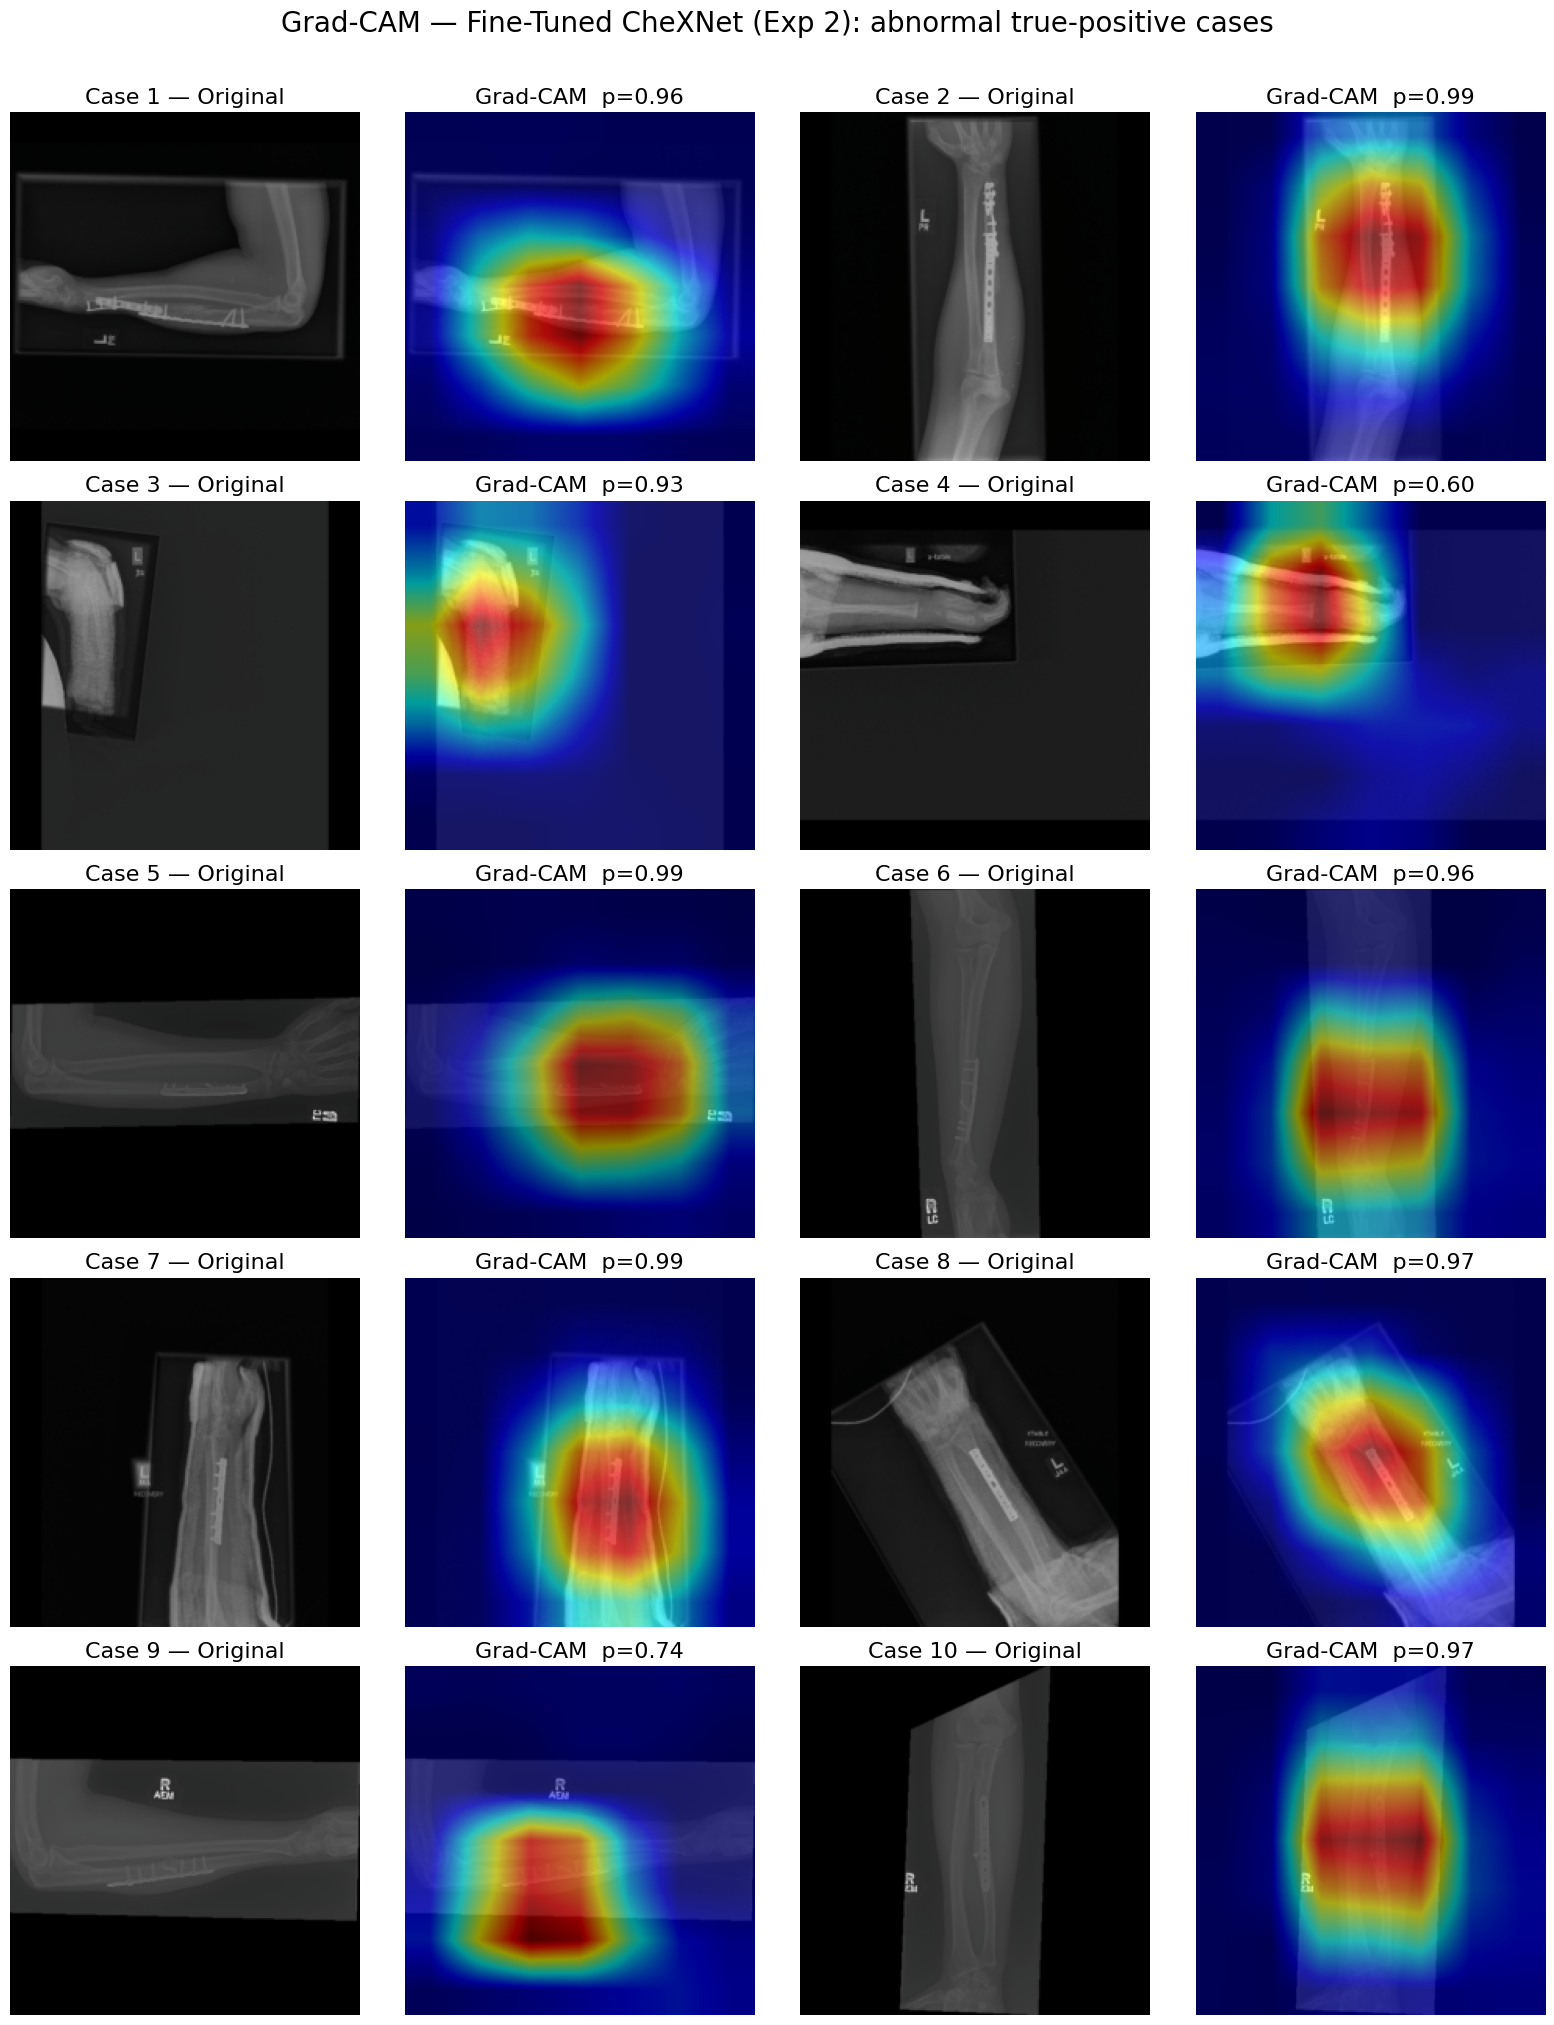

In [25]:
model = exp2_model; model.eval()
target_layer = model.densenet121.features.denseblock4            # last DenseNet block
mean, std = np.array(IMAGENET_MEAN), np.array(IMAGENET_STD)

# Collect 10 abnormal cases the model correctly predicts (true positives)
cases = []
for idx in range(len(valid_ds)):
    img, label = valid_ds[idx]
    if label.item() == 1.0:
        with torch.no_grad():
            p = torch.sigmoid(model(img.unsqueeze(0).to(DEVICE)).squeeze(1)).item()
        if p >= 0.5:
            cases.append((img.unsqueeze(0), p))
    if len(cases) == 10:
        break
print(f"Collected {len(cases)} true-positive abnormal cases")

per_row = 2
nrows = (len(cases) + per_row - 1) // per_row
fig, axes = plt.subplots(nrows, per_row * 2, figsize=(16, 4 * nrows)); axes = np.atleast_2d(axes)
for k, (img_tensor, p) in enumerate(cases):
    r, block = divmod(k, per_row); c0 = block * 2
    rgb = np.clip(img_tensor[0].cpu().numpy().transpose(1, 2, 0) * std + mean, 0, 1).astype(np.float32)
    inp = img_tensor.to(DEVICE).clone().requires_grad_(True)     # grad reaches target layer (frozen-safe)
    with GradCAM(model=model, target_layers=[target_layer]) as cam:
        gray = cam(input_tensor=inp, targets=[ClassifierOutputTarget(0)])[0]
    axes[r, c0].imshow(rgb); axes[r, c0].set_title(f"Case {k+1} — Original", fontsize=16); axes[r, c0].axis("off")
    axes[r, c0 + 1].imshow(show_cam_on_image(rgb, gray, use_rgb=True))
    axes[r, c0 + 1].set_title(f"Grad-CAM  p={p:.2f}", fontsize=16); axes[r, c0 + 1].axis("off")
for j in range(len(cases), nrows * per_row):
    r, block = divmod(j, per_row); axes[r, block * 2].axis("off"); axes[r, block * 2 + 1].axis("off")
plt.suptitle("Grad-CAM — Fine-Tuned CheXNet (Exp 2): abnormal true-positive cases", fontsize=20, y=1.01)
plt.tight_layout(); plt.savefig("gradcam_exp2_10cases.png", dpi=200, bbox_inches="tight"); plt.show()